In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# đọc dữ liệu
df = pd.read_csv("../data/agaricus-lepiota.data", header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
df.shape

(8124, 23)

In [4]:
# Gán nhãn các cột
column_names = [
    "poisonous",
    "cap_shape",
    "cap_surface",
    "cap_color",
    "bruises",
    "odor",
    "gill_attachment",
    "gill_spacing",
    "gill_size",
    "gill_color",
    "stalk_shape",
    "stalk_root",
    "stalk_surface_above_ring",
    "stalk_surface_below_ring",
    "stalk_color_above_ring",
    "stalk_color_below_ring",
    "veil_type",
    "veil_color",
    "ring_number",
    "ring_type",
    "spore_print_color",
    "population",
    "habitat"
]

df.columns = column_names

In [5]:
df.head()

,poisonous,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [6]:
df.shape

(8124, 23)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   poisonous                 8124 non-null   str  
 1   cap_shape                 8124 non-null   str  
 2   cap_surface               8124 non-null   str  
 3   cap_color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill_attachment           8124 non-null   str  
 7   gill_spacing              8124 non-null   str  
 8   gill_size                 8124 non-null   str  
 9   gill_color                8124 non-null   str  
 10  stalk_shape               8124 non-null   str  
 11  stalk_root                8124 non-null   str  
 12  stalk_surface_above_ring  8124 non-null   str  
 13  stalk_surface_below_ring  8124 non-null   str  
 14  stalk_color_above_ring    8124 non-null   str  
 15

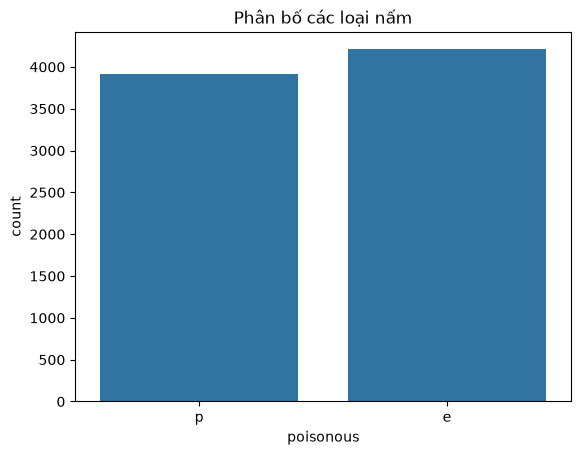

In [8]:
sns.countplot(data=df, x="poisonous")

plt.title("Phân bố các loại nấm")
plt.show()

In [9]:
df["poisonous"].value_counts()

poisonous
e    4208
p    3916
Name: count, dtype: int64

Dựa trên kết quả thống kê, số lượng mẫu nấm ăn được (4208) và nấm độc (3916) chiếm tỷ lệ tương đương nhau (52% và 48%). Do tập dữ liệu có sự cân bằng cao giữa hai lớp, dự án không cần áp dụng các kỹ thuật cân bằng dữ liệu như SMOTE, tránh được việc phát sinh dữ liệu nhiễu và giúp quá trình huấn luyện mô hình khách quan hơn.

In [10]:
(df == "?").sum()

poisonous                      0
cap_shape                      0
cap_surface                    0
cap_color                      0
bruises                        0
odor                           0
gill_attachment                0
gill_spacing                   0
gill_size                      0
gill_color                     0
stalk_shape                    0
stalk_root                  2480
stalk_surface_above_ring       0
stalk_surface_below_ring       0
stalk_color_above_ring         0
stalk_color_below_ring         0
veil_type                      0
veil_color                     0
ring_number                    0
ring_type                      0
spore_print_color              0
population                     0
habitat                        0
dtype: int64

Dataset không chứa giá trị NULL. Tuy nhiên, cột stalk_root có 2480 giá trị được biểu diễn bằng ký tự ?, tương ứng với dữ liệu bị thiếu. Các thuộc tính còn lại đầy đủ dữ liệu.

In [11]:
# tỷ lệ dữ liệu thiếu
(df["stalk_root"] == "?").mean() * 100

np.float64(30.526834071885773)

.mean(): Phương thức này tính giá trị trung bình của Series boolean. Trong Python, True được coi là 1 và False được coi là 0. Do đó, giá trị trung bình sẽ cho biết tỷ lệ phần trăm các giá trị trong cột "stalk_root" bằng "?". Cụ thể, nếu có 10 giá trị và 3 trong số đó là "?", thì giá trị trung bình sẽ là 3/10 = 0.3.

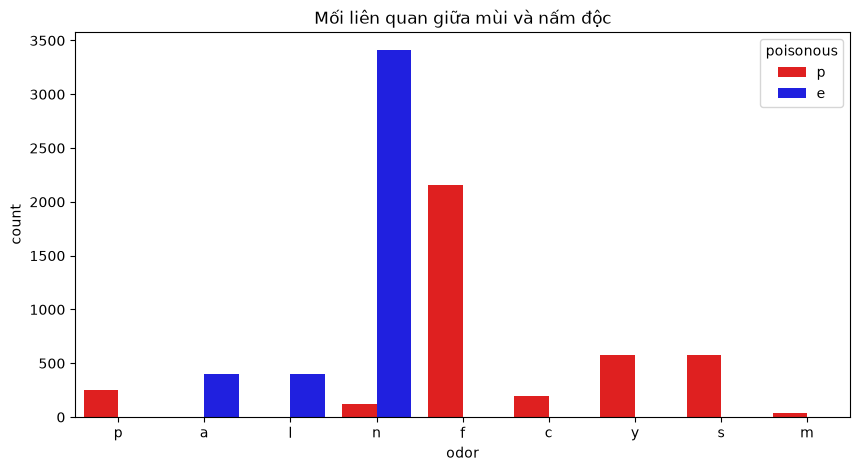

In [12]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="odor",
    hue="poisonous", 
    palette={"p": "red", "e": "blue"}
)

plt.title("Mối liên quan giữa mùi và nấm độc")
plt.show()

Dựa vào biểu đồ ta thấy:
- Các mùi như: a, l => là nấm ăn được
- Các mùi như: p, f, c, y, s, m => là nấm độc

=> Feature này giúp phân loại nấm rất mạnh.

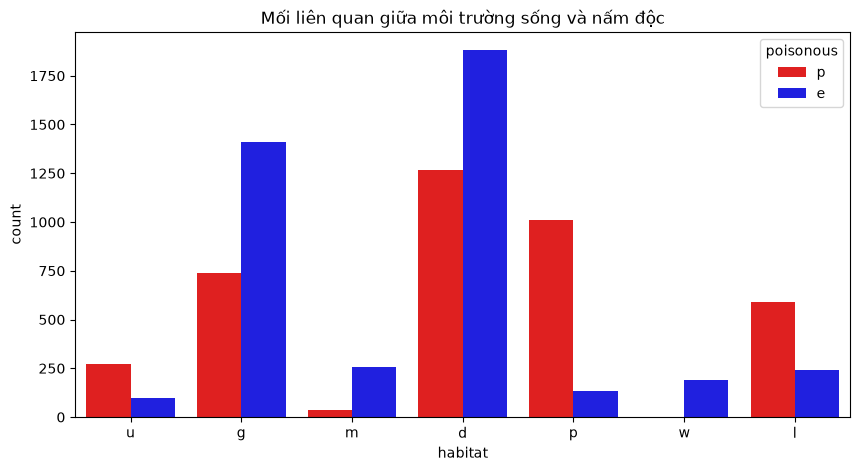

In [13]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="habitat",
    hue="poisonous",
    palette={"p": "red", "e": "blue"}
)

plt.title("Mối liên quan giữa môi trường sống và nấm độc")
plt.show()

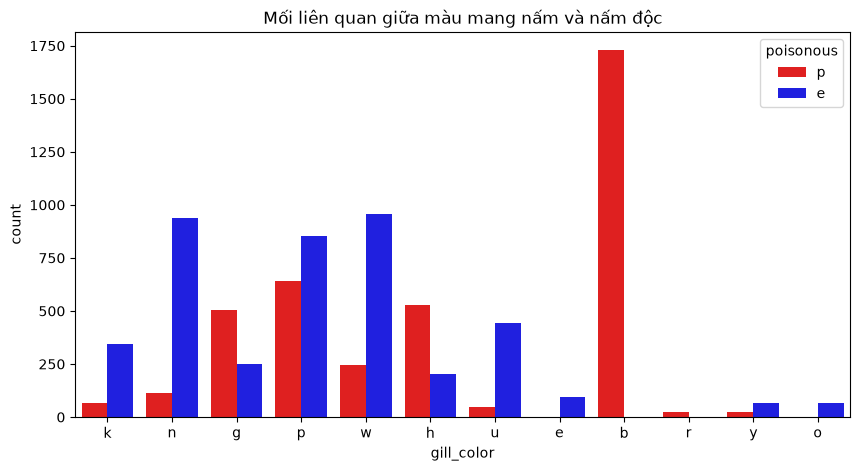

In [14]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="gill_color",
    hue="poisonous",
    palette={"p": "red", "e": "blue"}
)

plt.title("Mối liên quan giữa màu mang nấm và nấm độc")
plt.show()